# EDA song ngữ Trung–Việt (TMĐT) + Similarity bằng BAAI/bge-m3

**Input:** `bilingual_zh_vi.parquet` (~16K cặp sản phẩm TMĐT Trung–Việt)
**Mô hình:** [BAAI/bge-m3](https://huggingface.co/BAAI/bge-m3) — gọi thẳng từ Hugging Face Hub qua thư viện `transformers`.
**Công cụ:** pandas + pyarrow (EDA) · transformers + torch (embedding)

> ⚠️ **Schema thực tế:** file **không** có cột `zh_text` / `vi_text` như giả định ban đầu.
> Các cột văn bản thực tế là `title_zh`, `title_vi`, `description_zh`, `description_vi`.
> Notebook tự động dò cột (auto-detect) nên chạy được với cả 2 kiểu schema.


In [26]:
# Cài thư viện (chỉ cần trên Colab / máy chưa có). Bỏ qua nếu đã cài.
%pip install -q transformers torch pandas pyarrow matplotlib


## 0. Cài đặt & Import


In [27]:
import re
import hashlib
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)

# Nguồn dữ liệu: Hugging Face (đọc trực tiếp qua HTTPS).
# Muốn dùng file local thì đổi lại thành "bilingual_zh_vi.parquet".
HF_REPO = "ntquang0410/zh-vie_ecom"
HF_FILE = "data/snapshot/bilingual_zh_vi.parquet"
PARQUET_PATH = f"https://huggingface.co/datasets/{HF_REPO}/resolve/main/{HF_FILE}"

print("pandas", pd.__version__, "| torch", torch.__version__)


pandas 2.2.3 | torch 2.11.0+cu128


## 1. Tổng quan (shape, dtypes, null)


In [28]:
def load_parquet(path):
    """Đọc parquet từ URL hoặc đường dẫn local, fallback duckdb nếu pandas lỗi."""
    try:
        return pd.read_parquet(path)
    except ImportError as e:
        print("pandas thiếu thư viện, fallback duckdb:", e)
    except Exception as e:
        print("pandas lỗi:", type(e).__name__, e)
    import duckdb
    return duckdb.sql(f"SELECT * FROM read_parquet('{path}')").df()

df = load_parquet(PARQUET_PATH)

print("shape:", df.shape)
print("\n--- dtypes ---")
print(df.dtypes.to_string())
print("\n--- 5 dòng đầu ---")
display(df.head())

# --- Đếm null / rỗng theo từng cột (%) ---
# Cột nested (list/struct như attributes_zh) khi astype(str) ra "[]" chứ không rỗng,
# nên phải loại chúng khỏi phép đếm "rỗng" để tránh báo sai.
def is_text_col(s):
    return pd.api.types.is_string_dtype(s) or s.dtype == object

def is_nested_col(s):
    return s.map(type).isin([list, dict]).any()

def null_report(frame):
    rows = []
    n = len(frame)
    for c in frame.columns:
        s = frame[c]
        n_null = int(s.isna().sum())
        n_empty = 0
        if is_text_col(s) and not is_nested_col(s):
            try:
                n_empty = int(s.fillna("").astype(str).str.strip().eq("").sum())
            except Exception:
                n_empty = 0
        rows.append({
            "column": c,
            "dtype": str(s.dtype),
            "null_%": round(100 * n_null / n, 2),
            "empty_%": round(100 * n_empty / n, 2),
        })
    return pd.DataFrame(rows).sort_values("null_%", ascending=False)

null_df = null_report(df)
print("\n--- Null / rỗng theo cột (chỉ in cột có vấn đề) ---")
display(null_df[null_df["null_%"] > 0].reset_index(drop=True))
print("Số cột có null:", int((null_df["null_%"] > 0).sum()), "/", len(null_df))


shape: (16348, 30)

--- dtypes ---
product_id               object
title_zh                 object
title_vi                 object
description_zh           object
description_vi           object
category                 object
source_site              object
url                      object
crawl_time               object
worker                   object
keyword                  object
page                      int64
search_url               object
price                   float64
sales                   float64
province                 object
city                     object
biz_type                 object
shop                     object
is_ad                      bool
category_1688            object
category_id_1688         object
has_vi                     bool
attributes_zh            object
attributes_vi            object
n_attributes_zh           int64
n_attributes_vi           int64
n_attributes_aligned      int64
description_extra_zh     object
description_images        int64

--- 

,product_id,title_zh,title_vi,description_zh,description_vi,category,source_site,url,crawl_time,worker,...,category_1688,category_id_1688,has_vi,attributes_zh,attributes_vi,n_attributes_zh,n_attributes_vi,n_attributes_aligned,description_extra_zh,description_images
0,592582928262,轮胎刷 风口刷 轮毂刷发动机刷细节刷缝隙刷洗车清洁小毛刷洗车刷,"Bàn chải lốp, bàn chải cửa gió, bàn chải trung tâm, bàn chải động cơ, bàn ch...","材质: 超细纤维; 品牌: 柏尼士; 产地: 广州; 货号: 洗车刷子系列; 颜色: 1号竹柄刷, 2号圆头刷好, 3号黑色圆头刷, 4号小尖头刷, 5...",Chất liệu: sợi nhỏ; Thương hiệu: Perniz; Xuất xứ: Quảng Châu; Số mặt hàng: D...,auto,1688,https://detail.1688.com/offer/592582928262.html,2026-09-17T19:28:45+00:00,worker_nhat_anh,...,汽车清洁工具,124742030,True,"[{'name': '材质', 'values': ['超细纤维']}, {'name': '品牌', 'values': ['柏尼士']}, {'na...","[{'name': 'Chất liệu', 'values': ['sợi nhỏ']}, {'name': 'Xuất xứ', 'values':...",11,11,11,,12
1,741400188461,汽车座椅后背收纳袋可爱卡通车载垃圾桶创意多功能汽车内饰防踢垫,"Túi đựng đồ phía sau ghế ô tô, thùng rác ô tô hoạt hình dễ thương, đệm chống...","材质: 皮革; 功能: 防水, 抗压, 可定制, 带提手; 使用位置: 座椅后背; 适用汽车品牌: 通用; 品牌: 羽岑; 使用方式: 悬挂式; 加工定...","Chất liệu: Da; Chức năng: Chống nước, Chống nén, Có thể tùy chỉnh, Có tay cầ...",auto,1688,https://detail.1688.com/offer/741400188461.html,2026-09-17T19:29:06+00:00,worker_nhat_anh,...,车用置物袋/置物箱,1032116,True,"[{'name': '材质', 'values': ['皮革']}, {'name': '功能', 'values': ['防水', '抗压', '可定...","[{'name': 'Thương hiệu', 'values': ['Vũ Cen']}, {'name': 'Chất liệu', 'value...",17,17,17,,20
2,916030328790,汽车临时停车牌女挪车电话牌车载手机号码牌创意摆件装饰用品大全,Biển báo đỗ xe ô tô tạm thời Biển báo điện thoại di động ô tô biển số điện t...,材质: 塑料; 品牌: other/其他; 类型: 隐藏式; 产地: 义乌; 加工定制: 否; 尺寸: 15; 型号: 0003; 适用送礼场合: 其他...,Chất liệu: Nhựa; Thương hiệu: Khác/khác; Loại: Kiểu ẩn; Xuất xứ: Nghĩa Ô; Gi...,auto,1688,https://detail.1688.com/offer/916030328790.html,2026-09-17T19:29:27+00:00,worker_nhat_anh,...,临时停车牌,201327101,True,"[{'name': '材质', 'values': ['塑料']}, {'name': '品牌', 'values': ['other/其他']}, {...","[{'name': 'Thương hiệu', 'values': ['Khác/khác']}, {'name': 'Chất liệu', 'va...",15,15,15,,6
3,789617923790,厂家批发车载停车牌隐藏式挪车金属号码牌夜光创意摆件汽车用品,Nhà sản xuất bán buôn tấm đỗ xe ô tô ẩn tấm số kim loại di chuyển ô tô dạ qu...,材质: 金属; 功能: 夜光; 品牌: 登驿诺; 类型: 隐藏式; 产地: 中国地区; 加工定制: 是; 尺寸: 125*18mm; 型号: 汽车隐藏式...,Chất liệu: Kim loại; chức năng: Phát sáng trong bóng tối; Thương hiệu: Dengn...,auto,1688,https://detail.1688.com/offer/789617923790.html,2026-09-17T19:29:46+00:00,worker_nhat_anh,...,临时停车牌,201327101,True,"[{'name': '材质', 'values': ['金属']}, {'name': '功能', 'values': ['夜光']}, {'name'...","[{'name': 'Thương hiệu', 'values': ['Dengnuo']}, {'name': 'Chất liệu', 'valu...",16,16,16,,18
4,859282894083,汽车摆件五星红旗党旗车载装饰用品伸缩 小红旗汽车香水工厂代发,Đồ trang trí ô tô Cờ đỏ năm sao Cờ đảng Đồ trang trí ô tô có thể thu vào Nhà...,风格: 中国传统; 材质: 玻璃; 功能: 祝福; 品牌: santigo; 加工定制: 是; 是否专利货源: 否; 货号: 旗帜摆件; 颜色分类: 金...,Phong cách: Truyền thống Trung Quốc; Chất liệu: Thủy tinh; Chức năng: Chúc p...,auto,1688,https://detail.1688.com/offer/859282894083.html,2026-09-17T19:30:12+00:00,worker_nhat_anh,...,汽车摆件,125086011,True,"[{'name': '风格', 'values': ['中国传统']}, {'name': '材质', 'values': ['玻璃']}, {'nam...","[{'name': 'Chất liệu', 'values': ['Thủy tinh']}, {'name': 'Phong cách', 'val...",9,9,9,,17



--- Null / rỗng theo cột (chỉ in cột có vấn đề) ---


,column,dtype,null_%,empty_%
0,biz_type,object,16.50,16.50
1,sales,float64,3.32,0.00
2,city,object,0.10,0.10
3,province,object,0.01,0.01


Số cột có null: 4 / 30


## 1b. Loại bỏ dòng trùng (title_zh == title_vi)

Chỉ loại các dòng có `title_zh` trùng `title_vi` (nghi chưa dịch / chép nguyên).
Các dòng chứa tiếng Anh được **giữ lại** để phục vụ EDA trên dữ liệu đầy đủ.

> Có thể bật lại bộ lọc tiếng Anh bằng cách đổi `mask_drop = mask_same` thành
> `mask_drop = mask_same | mask_en` ở cell bên dưới.


In [29]:
# --- Chỉ loại dòng title_zh == title_vi (GIỮ LẠI tiếng Anh để EDA) ---
n_before = len(df)

zh = df["title_zh"].fillna("").astype(str).str.strip()
vi = df["title_vi"].fillna("").astype(str).str.strip()

# (1) title_zh trùng title_vi (thường là chưa dịch / chép nguyên)
mask_same = (zh == vi)

# (2) [TẠM TẮT] Không loại tiếng Anh — giữ lại để EDA trên dữ liệu đầy đủ.
#     Muốn loại tiếng Anh: đổi dòng bên dưới thành  mask_drop = mask_same | mask_en
EN_PATTERN = r"[A-Za-z]"
mask_en = zh.str.contains(EN_PATTERN, regex=True)

mask_drop = mask_same  # chỉ loại dòng trùng nhau, KHÔNG loại tiếng Anh
df = df[~mask_drop].copy().reset_index(drop=True)

print(f"Tổng dòng ban đầu: {n_before}")
print(f"  - Loại do title_zh == title_vi: {int(mask_same.sum())}")
print(f"  - Dòng có tiếng Anh (GIỮ LẠI):  {int(mask_en.sum())}")
print(f"  - Số dòng còn lại:               {len(df)}")


Tổng dòng ban đầu: 16348
  - Loại do title_zh == title_vi: 2
  - Loại do title_zh chứa tiếng Anh: 6249
  - Chồng lấn (vừa trùng vừa EN): 2
  - Số dòng còn lại:              10099


## 2. Thống kê văn bản (độ dài ký tự & token)


Cột zh dùng để phân tích: title_zh
Cột vi dùng để phân tích: title_vi

--- Thống kê độ dài (ký tự) ---


,zh_chars,vi_chars
count,10099.0,10099.0
mean,30.2,125.3
std,1.6,23.3
min,3.0,5.0
50%,30.0,125.0
95%,32.0,163.0
99%,33.0,190.0
max,38.0,270.0


--- Thống kê token ước lượng ---


,zh_tokens,vi_tokens
count,10099.0,10099.0
mean,30.1,28.0
std,1.7,5.1
min,3.0,2.0
50%,30.0,28.0
95%,32.0,36.0
99%,33.0,42.0
max,38.0,63.0


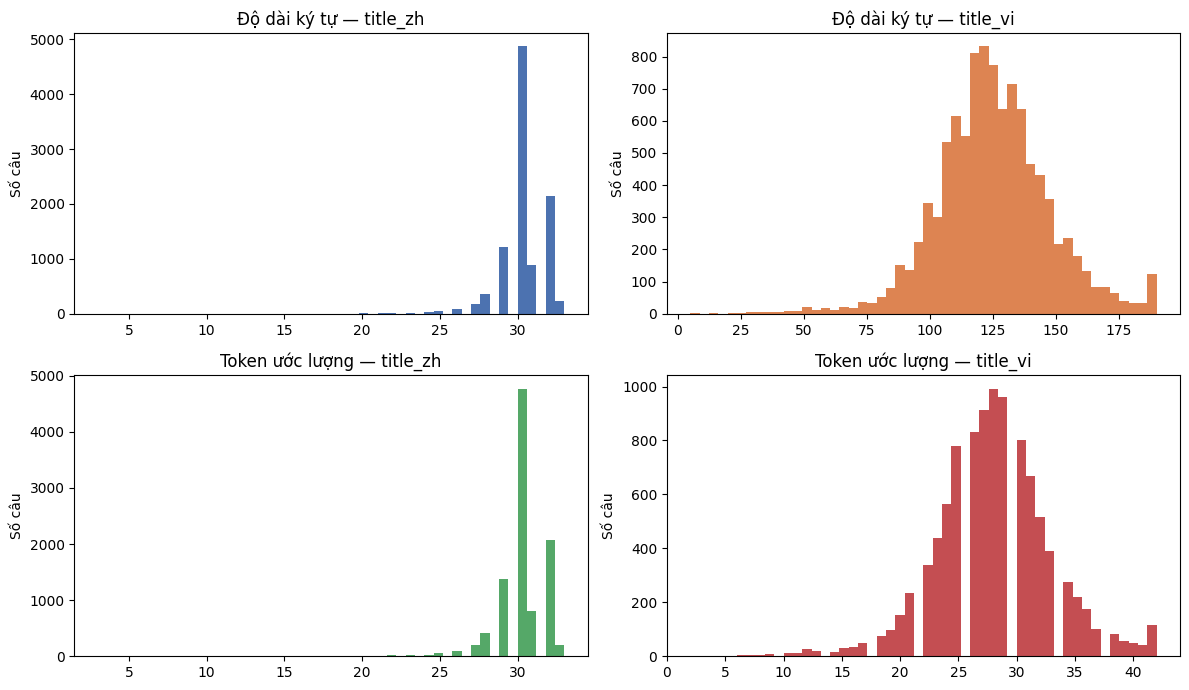


--- Tỷ lệ độ dài KÝ TỰ (vi/zh) ---
count    10099.000
mean         4.154
std          0.777
min          0.500
50%          4.125
95%          5.438
99%          6.400
max         10.077

--- Tỷ lệ TOKEN (vi_words / zh_chars) — dùng để phát hiện lệch ---
count    10099.000
mean         0.930
std          0.171
min          0.167
50%          0.933
95%          1.200
99%          1.414
max          2.192

Outlier theo tỷ lệ KÝ TỰ (>3.0 hoặc <0.3): 9613 (95.2%)  <- ngưỡng không phù hợp với zh->vi
Outlier theo tỷ lệ TOKEN  (>3.0 hoặc <0.3): 10 (0.10%)  <- dùng cái này


In [30]:
def is_flat_text(s):
    if not (pd.api.types.is_string_dtype(s) or s.dtype == object):
        return False
    return not s.map(type).isin([list, dict]).any()

def pick_col(frame, candidates):
    for c in candidates:
        if c in frame.columns and is_flat_text(frame[c]):
            return c
    return None

ZH_COL = pick_col(df, ["zh_text", "title_zh", "description_zh"])
VI_COL = pick_col(df, ["vi_text", "title_vi", "description_vi"])
print("Cột zh dùng để phân tích:", ZH_COL)
print("Cột vi dùng để phân tích:", VI_COL)

# Token ước lượng: tiếng Trung ~ 1 ký tự = 1 token; tiếng Việt ~ tách theo khoảng trắng
def est_tokens_zh(s):
    return s.fillna("").astype(str).str.replace(r"\s+", "", regex=True).str.len()

def est_tokens_vi(s):
    return s.fillna("").astype(str).str.split().str.len()

try:
    len_zh = df[ZH_COL].fillna("").astype(str).str.len()
    len_vi = df[VI_COL].fillna("").astype(str).str.len()
    tok_zh = est_tokens_zh(df[ZH_COL])
    tok_vi = est_tokens_vi(df[VI_COL])
except Exception as e:
    print("Lỗi tính độ dài:", e)
    len_zh = len_vi = tok_zh = tok_vi = pd.Series(dtype=float)

print("\n--- Thống kê độ dài (ký tự) ---")
display(pd.DataFrame({
    "zh_chars": len_zh.describe(percentiles=[.5, .95, .99]),
    "vi_chars": len_vi.describe(percentiles=[.5, .95, .99]),
}).round(1))

print("--- Thống kê token ước lượng ---")
display(pd.DataFrame({
    "zh_tokens": tok_zh.describe(percentiles=[.5, .95, .99]),
    "vi_tokens": tok_vi.describe(percentiles=[.5, .95, .99]),
}).round(1))

# --- Histogram cơ bản ---
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0, 0].hist(len_zh.clip(upper=len_zh.quantile(.99)), bins=50, color="#4C72B0")
axes[0, 0].set_title(f"Độ dài ký tự — {ZH_COL}")
axes[0, 1].hist(len_vi.clip(upper=len_vi.quantile(.99)), bins=50, color="#DD8452")
axes[0, 1].set_title(f"Độ dài ký tự — {VI_COL}")
axes[1, 0].hist(tok_zh.clip(upper=tok_zh.quantile(.99)), bins=50, color="#55A868")
axes[1, 0].set_title(f"Token ước lượng — {ZH_COL}")
axes[1, 1].hist(tok_vi.clip(upper=tok_vi.quantile(.99)), bins=50, color="#C44E52")
axes[1, 1].set_title(f"Token ước lượng — {VI_COL}")
for ax in axes.ravel():
    ax.set_ylabel("Số câu")
plt.tight_layout()
plt.show()

# --- Tỷ lệ độ dài zh/vi ---
# Tỷ lệ KÝ TỰ vi/zh luôn ~4.0 (tiếng Việt nhiều ký tự hơn) -> ngưỡng >3.0/<0.3 flag ~91%.
# => Dùng tỷ lệ TOKEN (số từ vi / số ký tự zh), kỳ vọng ~0.9.
ratio_char = (len_vi / len_zh.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
ratio_tok = (tok_vi / tok_zh.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)

print("\n--- Tỷ lệ độ dài KÝ TỰ (vi/zh) ---")
print(ratio_char.describe(percentiles=[.5, .95, .99]).round(3).to_string())
print("\n--- Tỷ lệ TOKEN (vi_words / zh_chars) — dùng để phát hiện lệch ---")
print(ratio_tok.describe(percentiles=[.5, .95, .99]).round(3).to_string())

RATIO_HI, RATIO_LO = 3.0, 0.3
n_char_out = int(((ratio_char > RATIO_HI) | (ratio_char < RATIO_LO)).sum())
n_tok_out = int(((ratio_tok > RATIO_HI) | (ratio_tok < RATIO_LO)).sum())
print(f"\nOutlier theo tỷ lệ KÝ TỰ (>{RATIO_HI} hoặc <{RATIO_LO}): {n_char_out} "
      f"({100*n_char_out/len(df):.1f}%)  <- ngưỡng không phù hợp với zh->vi")
print(f"Outlier theo tỷ lệ TOKEN  (>{RATIO_HI} hoặc <{RATIO_LO}): {n_tok_out} "
      f"({100*n_tok_out/len(df):.2f}%)  <- dùng cái này")


## 3. Từ vựng & thuật ngữ TMĐT


In [31]:
# --- Top 30 token phổ biến mỗi ngôn ngữ (lowercase + strip) ---
def top_tokens(series, n=30, lang="vi"):
    txt = series.fillna("").astype(str).str.lower().str.strip()
    if lang == "zh":
        # tiếng Trung: tách theo ký tự Hán (bỏ khoảng trắng & dấu câu)
        toks = txt.str.findall(r"[\u4e00-\u9fff]")
    else:
        toks = txt.str.findall(r"\w+", flags=re.UNICODE)
    cnt = Counter(t for row in toks for t in row)
    return pd.DataFrame(cnt.most_common(n), columns=["token", "count"])

try:
    print(f"--- Top 30 token ZH ({ZH_COL}) ---")
    display(top_tokens(df[ZH_COL], 30, "zh"))
    print(f"--- Top 30 token VI ({VI_COL}) ---")
    display(top_tokens(df[VI_COL], 30, "vi"))
except Exception as e:
    print("Lỗi thống kê từ vựng:", e)

# --- Ký tự HTML còn sót ---
HTML_PATTERNS = {
    "entity (&amp; &lt; &gt; &quot; &#...);": r"&(?:amp|lt|gt|quot|nbsp|#\d+);",
    "tag (<...>)": r"<[^>]{1,80}>",
    "url (http/https)": r"https?://",
}
print("\n--- Ký tự HTML / URL còn sót ---")
rows = []
for name, pat in HTML_PATTERNS.items():
    for col in [c for c in [ZH_COL, VI_COL] if c]:
        try:
            n = int(df[col].fillna("").astype(str).str.contains(pat, regex=True).sum())
        except Exception:
            n = -1
        rows.append({"pattern": name, "column": col, "rows": n})
display(pd.DataFrame(rows))

# --- Thuật ngữ TMĐT ---
ZH_TERMS = ["包邮", "正品", "代购", "旗舰店", "促销", "折扣"]
VI_TERMS = ["freeship", "chính hãng", "khuyến mãi", "giảm giá", "ship", "sale"]

def count_terms(frame, terms, cols):
    out = []
    for t in terms:
        row = {"term": t}
        for c in cols:
            if c is None:
                continue
            try:
                row[c] = int(frame[c].fillna("").astype(str).str.lower()
                             .str.contains(re.escape(t.lower()), regex=True).sum())
            except Exception:
                row[c] = -1
        out.append(row)
    return pd.DataFrame(out)

print("\n--- Thuật ngữ TMĐT tiếng Trung ---")
ZH_TEXT_COLS = [c for c in df.columns if c.endswith("_zh") and is_flat_text(df[c])]
display(count_terms(df, ZH_TERMS, ZH_TEXT_COLS))
print("--- Thuật ngữ TMĐT tiếng Việt ---")
VI_TEXT_COLS = [c for c in df.columns if c.endswith("_vi") and is_flat_text(df[c])]
display(count_terms(df, VI_TERMS, VI_TEXT_COLS))


--- Top 30 token ZH (title_zh) ---


,token,count
0,包,7308
1,鞋,5913
2,款,4493
3,女,4209
4,新,4067
5,男,3171
6,茶,2914
7,面,2735
8,箱,2659
9,小,2516


--- Top 30 token VI (title_vi) ---


,token,count
0,giày,5100
1,đồ,4422
2,cho,4406
3,túi,3855
4,hộp,3638
5,mới,3442
6,nữ,3320
7,đựng,2969
8,và,2872
9,bộ,2811



--- Ký tự HTML / URL còn sót ---


,pattern,column,rows
0,entity (&amp; &lt; &gt; &quot; &#...);,title_zh,0
1,entity (&amp; &lt; &gt; &quot; &#...);,title_vi,0
2,tag (<...>),title_zh,0
3,tag (<...>),title_vi,0
4,url (http/https),title_zh,0
5,url (http/https),title_vi,0



--- Thuật ngữ TMĐT tiếng Trung ---


,term,title_zh,description_zh,attributes_zh,description_extra_zh
0,包邮,43,16,16,33
1,正品,148,13,13,62
2,代购,3,0,0,0
3,旗舰店,21,3,3,7
4,促销,0,53,53,20
5,折扣,0,0,0,7


--- Thuật ngữ TMĐT tiếng Việt ---


,term,title_vi,description_vi,attributes_vi
0,freeship,0,0,0
1,chính hãng,166,42,42
2,khuyến mãi,3,53,53
3,giảm giá,7,16,16
4,ship,67,65,65
5,sale,0,2,2


## 4. Trùng lặp


In [32]:
# LƯU Ý: df.duplicated() trên TOÀN BỘ frame sẽ lỗi nếu có cột nested (list/struct)
# như attributes_zh / attributes_vi -> phải giới hạn ở các cột văn bản.
TEXT_COLS = [c for c in [ZH_COL, VI_COL] if c]
PAIR_COLS = [c for c in ["title_zh", "title_vi", "description_zh", "description_vi"] if c in df.columns]

def dup_count(frame, cols, label):
    try:
        n = int(frame[cols].duplicated(keep="first").sum())
    except Exception as e:
        n = -1
        print(f"  ! {label}: {e}")
    print(f"{label:<42} {n:>7}  ({100*n/len(frame):.2f}%)")
    return n

print("--- Đếm trùng lặp ---")
dup_pair = dup_count(df, TEXT_COLS, f"Cặp trùng chính xác {TEXT_COLS}")
dup_full = dup_count(df, PAIR_COLS, "Trùng toàn bộ 4 cột văn bản")
dup_zh = dup_count(df, [ZH_COL], f"Câu ZH trùng ({ZH_COL})")
dup_vi = dup_count(df, [VI_COL], f"Câu VI trùng ({VI_COL})")
if "product_id" in df.columns:
    dup_count(df, ["product_id"], "product_id trùng")

# Kiểm chứng bằng hashlib (md5) trên cặp câu -> phải khớp với df.duplicated()
try:
    h = (df[ZH_COL].fillna("").astype(str) + "\x1f" + df[VI_COL].fillna("").astype(str)) \
        .map(lambda s: hashlib.md5(s.encode("utf-8")).hexdigest())
    print(f"\nHash md5 trùng (kiểm chứng): {int(h.duplicated().sum())}  "
          f"-> khớp với df.duplicated(): {int(h.duplicated().sum()) == dup_pair}")
except Exception as e:
    print("Lỗi hash:", e)

if dup_pair > 0:
    print("\n--- Ví dụ cặp trùng ---")
    display(df[df[TEXT_COLS].duplicated(keep=False)].sort_values(TEXT_COLS).head(6))


--- Đếm trùng lặp ---
Cặp trùng chính xác ['title_zh', 'title_vi']     124  (1.23%)
Trùng toàn bộ 4 cột văn bản                      6  (0.06%)
Câu ZH trùng (title_zh)                        283  (2.80%)
Câu VI trùng (title_vi)                        129  (1.28%)
product_id trùng                                 0  (0.00%)

Hash md5 trùng (kiểm chứng): 124  -> khớp với df.duplicated(): True

--- Ví dụ cặp trùng ---


,product_id,title_zh,title_vi,description_zh,description_vi,category,source_site,url,crawl_time,worker,...,category_1688,category_id_1688,has_vi,attributes_zh,attributes_vi,n_attributes_zh,n_attributes_vi,n_attributes_aligned,description_extra_zh,description_images
8225,1051927103819,2026春季新款米白色低帮帆布鞋复古男款百搭鞋子爆款板鞋轻便男鞋,"Giày vải canvas cổ thấp màu trắng kem, mẫu mới mùa xuân 2026, phong cách ret...",鞋面材质: 超纤; 品牌: 无品牌; 功能: 透气; 鞋底材质: 橡胶; 内里材质: 网纱; 鞋垫材质: 其它; 鞋底工艺: 注塑鞋; 鞋头形状: 圆头...,Chất liệu mặt giày: Siêu sợi; Thương hiệu: Không thương hiệu; Chức năng: Tho...,shoes,1688,https://detail.1688.com/offer/1051927103819.html,2026-09-21T19:01:03+00:00,worker_huy,...,男式板鞋,126442003,True,"[{'name': '鞋面材质', 'values': ['超纤']}, {'name': '品牌', 'values': ['无品牌']}, {'na...","[{'name': 'Hình dạng mũi giày', 'values': ['Mũi tròn']}, {'name': 'Loại nguồ...",35,35,35,,14
9974,1051143665641,2026春季新款米白色低帮帆布鞋复古男款百搭鞋子爆款板鞋轻便男鞋,"Giày vải canvas cổ thấp màu trắng kem, mẫu mới mùa xuân 2026, phong cách ret...",鞋面材质: 超纤; 品牌: 无品牌; 功能: 透气; 鞋底材质: 橡胶; 内里材质: 网纱; 鞋垫材质: 其它; 鞋底工艺: 注塑鞋; 鞋头形状: 圆头...,Chất liệu mặt giày: Siêu sợi; Thương hiệu: Không thương hiệu; Chức năng: Tho...,shoes,1688,https://detail.1688.com/offer/1051143665641.html,2026-09-21T12:08:55+00:00,worker_nhat_anh,...,男式板鞋,126442003,True,"[{'name': '鞋面材质', 'values': ['超纤']}, {'name': '品牌', 'values': ['无品牌']}, {'na...","[{'name': 'Hình dạng mũi giày', 'values': ['Mũi tròn']}, {'name': 'Loại nguồ...",35,35,35,,14
7887,1051887137284,2026春款复古拼色运动鞋女软底透气休闲鞋轻便系带时装鞋多色女鞋,"Giày thể thao nữ phối màu retro mẫu xuân 2026, đế mềm thoáng khí, giày casua...",款式: 阿甘鞋; 功能: 透气; 产品类别: 阿甘鞋; 鞋面材质: pu+网布; 内里材质: 网纱; 品牌: 无; 鞋底材质: 橡塑; 产地: 浙江台州...,Kiểu dáng: Giày Forrest Gump2; Chức năng: Thoáng khí; Danh mục sản phẩm: Già...,shoes,1688,https://detail.1688.com/offer/1051887137284.html,2026-09-21T16:51:31+00:00,worker_huy,...,女式运动单鞋,126552002,True,"[{'name': '款式', 'values': ['阿甘鞋']}, {'name': '功能', 'values': ['透气']}, {'name...","[{'name': 'Danh mục sản phẩm', 'values': ['Giày Forrest Gump1']}, {'name': '...",41,41,41,,11
8254,1054595420023,2026春款复古拼色运动鞋女软底透气休闲鞋轻便系带时装鞋多色女鞋,"Giày thể thao nữ phối màu retro mẫu xuân 2026, đế mềm thoáng khí, giày casua...",款式: 阿甘鞋; 功能: 透气; 产品类别: 阿甘鞋; 鞋面材质: pu+网布; 内里材质: 网纱; 品牌: 无; 鞋底材质: 橡塑; 产地: 浙江台州...,Kiểu dáng: Giày Forrest Gump1; Chức năng: Thoáng khí; Danh mục sản phẩm: Già...,shoes,1688,https://detail.1688.com/offer/1054595420023.html,2026-09-21T19:10:04+00:00,worker_huy,...,女式运动单鞋,126552002,True,"[{'name': '款式', 'values': ['阿甘鞋']}, {'name': '功能', 'values': ['透气']}, {'name...","[{'name': 'Danh mục sản phẩm', 'values': ['Giày Forrest Gump2']}, {'name': '...",41,41,41,,11
9702,1026357126805,2026春款复古拼色运动鞋女软底透气休闲鞋轻便系带时装鞋多色女鞋,"Giày thể thao nữ phối màu retro mẫu xuân 2026, đế mềm thoáng khí, giày casua...",款式: 阿甘鞋; 功能: 透气; 产品类别: 阿甘鞋; 鞋面材质: pu+网布; 内里材质: 网纱; 品牌: 无; 鞋底材质: 橡塑; 产地: 浙江台州...,Kiểu dáng: Giày Forrest Gump2; Chức năng: Thoáng khí; Danh mục sản phẩm: Già...,shoes,1688,https://detail.1688.com/offer/1026357126805.html,2026-09-21T10:40:17+00:00,worker_nhat_anh,...,女式运动单鞋,126552002,True,"[{'name': '款式', 'values': ['阿甘鞋']}, {'name': '功能', 'values': ['透气']}, {'name...","[{'name': 'Danh mục sản phẩm', 'values': ['Giày Forrest Gump1']}, {'name': '...",41,41,41,,11
2114,925316983241,20×30×40小型迷你轻便登机箱女旅行春秋航空14寸静音行李拉杆箱,20 × 30 × 40 Hộp đựng hành lý di động mini cỡ nhỏ dành cho nữ du lịch Spring...,材质: ABS; 开盖方式: 拉链; 滚轮样式: 万向轮; 功能: 其他; 锁的类型: 挂锁; 里料质地: 其他; 货号: 昇疚; 适用性别: 中性/男...,材质: ABS; Cách mở nắp: Khóa kéo; Kiểu dáng con lăn: Bánh đa năng; Chức năng: ...,bags,1688,https://detail.1688.com/offer/925316983241.html,2026-09-19T15:03:39+00:00,worker_huy,...,旅行箱,10283,True,"[{'name': '材质', 'values': ['ABS']}, {'name': '开盖方式', 'values': ['拉链']}, {'na...","[{'name': '材质', 'values': ['ABS']}, {'name': '里料质地', 'values': ['其他']}, {'na...",19,19,19,,13


## 5. Similarity Trung–Việt bằng BAAI/bge-m3 (từ Hugging Face)

Gọi thẳng mô hình `BAAI/bge-m3` từ Hugging Face Hub qua thư viện `transformers`
(`AutoTokenizer` + `AutoModel`), dùng **CLS pooling** + **chuẩn hoá L2** (đúng theo
`1_Pooling/config.json`) → cosine similarity = tích vô hướng.


In [33]:
# --- Nạp bge-m3 thẳng từ Hugging Face Hub ---
MODEL_NAME = "BAAI/bge-m3"

def get_device():
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
print("Thiết bị:", DEVICE)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

def encode(texts, max_length=512, batch_size=64):
    """Encode danh sách văn bản -> tensor (n, 1024) đã chuẩn hoá L2."""
    if isinstance(texts, str):
        texts = [texts]
    texts = ["" if t is None else str(t) for t in texts]
    embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=max_length, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out = model(**enc)
        # CLS pooling (đúng cấu hình bge-m3)
        e = out.last_hidden_state[:, 0, :]
        e = F.normalize(e, p=2, dim=1)
        embs.append(e.cpu())
    return torch.cat(embs, dim=0)


Thiết bị: cuda


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [34]:
# --- Tính similarity cho tiêu đề (title_zh vs title_vi) ---
# SAMPLE = None để chạy toàn bộ 16K cặp (CPU ~ vài phút). Đặt số để chạy demo nhanh.
SAMPLE = None

work = df[[ZH_COL, VI_COL]].copy()
work[ZH_COL] = work[ZH_COL].fillna("").astype(str)
work[VI_COL] = work[VI_COL].fillna("").astype(str)
if SAMPLE:
    work = work.sample(SAMPLE, random_state=42)

zh_emb = encode(work[ZH_COL].tolist())
vi_emb = encode(work[VI_COL].tolist())
sim = (zh_emb * vi_emb).sum(dim=1)  # cosine = dot product (đã chuẩn hoá)
work["sim_score"] = sim.numpy()

print("--- Phân bố similarity bge-m3 (title) ---")
print(work["sim_score"].describe(percentiles=[.05, .25, .5, .75, .95]).round(3).to_string())

# Gắn sim_score về df gốc (theo index) để dùng ở phần xuất báo cáo
df["sim_score"] = np.nan
df.loc[work.index, "sim_score"] = work["sim_score"]

SIM_THRESHOLD = 0.5
print(f"\nSố cặp similarity < {SIM_THRESHOLD}: "
      f"{int((work['sim_score'] < SIM_THRESHOLD).sum())} "
      f"({100*(work['sim_score'] < SIM_THRESHOLD).mean():.2f}%)")

print("\n--- 20 cặp similarity thấp nhất (nghi dịch lệch) ---")
display(work.nsmallest(20, "sim_score")[[ZH_COL, VI_COL, "sim_score"]])

print("\n--- 5 cặp similarity cao nhất (dịch khớp tốt) ---")
display(work.nlargest(5, "sim_score")[[ZH_COL, VI_COL, "sim_score"]])


--- Phân bố similarity bge-m3 (title) ---
count    10099.000
mean         0.693
std          0.056
min          0.440
5%           0.591
25%          0.657
50%          0.697
75%          0.734
95%          0.775
max          0.864

Số cặp similarity < 0.5: 13 (0.13%)

--- 20 cặp similarity thấp nhất (nghi dịch lệch) ---


,title_zh,title_vi,sim_score
5746,严选凤凰单枞鸭屎香蜜兰香凤凰单从高山乌龙茶罐装茶叶礼盒装送礼,Phân vịt Phoenix Dancong được lựa chọn cẩn thận,0.439909
5963,源头工厂普洱熟茶云南勐海糯香熟普洱茶陈年发酵熟茶散装茶叶批发,"Trà Phổ Nhĩ chín Vân Nam Mạnh Hải hương nếp, trà Phổ Nhĩ chín ủ lâu năm, trà...",0.464426
2254,一枝春玻尿酸补水面膜美白保湿提亮肤色紧致滋润贴片面膜厂家批发,"Yizhichun Hyaluronic Acid Hydrating Mask Làm trắng, dưỡng ẩm, làm sáng da, l...",0.474327
5958,凤凰单枞鸭屎香茶叶高端罐装特级老丛地标认证潮州单丛茶散批代发,"Trà Phượng Hoàng Đan Công Yashixiang, trà cao cấp đóng hộp, được chứng nhận ...",0.474828
3931,怡口莲夹心太妃糖经典巧克力味混合独立小包散装糖果结婚喜糖奶糖,Kẹo bơ cứng bánh kẹo sô cô la cổ điển trộn kẹo gói nhỏ độc lập kẹo cưới kẹo ...,0.475174
5777,凤凰单枞蜜兰香茶叶散批潮州乌岽老枞单丛茶地标认证厂家批发代发,"Trà Phượng Hoàng Đan Công hương hoa lan mật ong, trà lá rời từ Triều Châu, đ...",0.475301
3960,【包邮】香辣鸭翅湖南特色酱麻辣板鸭鸭货翅尖追剧卤味零食小吃,[Miễn phí vận chuyển] Cánh vịt cay sốt đặc biệt Hồ Nam,0.488192
4139,广东潮州凤凰单丛蜜兰香乌龙茶单枞茶蜜香单枞茶场乌叶散茶礼盒,Quảng Đông Triều Châu Phượng Hoàng Dancong Mật ong Trà ô long Trà ô long Dan...,0.492231
3804,家城沙嗲素牛肉干怀旧辣条牛肉粒儿时经典校园素肉沙爹素小吃零食,"Thịt bò khô sa tế Jiacheng, thịt bò cay hoài cổ, món ăn nhẹ sa tế",0.494015
3942,香菇豆干混合重庆产麻辣香辣零食大全各种各样嫩豆腐干不辣小吃的,Đậu phụ khô nấm trộn với đồ ăn nhẹ cay và cay từ Trùng Khánh,0.496863



--- 5 cặp similarity cao nhất (dịch khớp tốt) ---


,title_zh,title_vi,sim_score
8641,儿童超大号120救护车玩具可开5门音乐故事仿真模型汽车男孩3-6岁,Đồ chơi xe cứu thương 120 siêu lớn dành cho trẻ em có thể mở 5 cửa câu chuyệ...,0.863630
3038,2026新款托特包大容量女包韩版简约单肩包女通勤百搭休闲手提包包,"Túi tote kiểu mới 2026, túi nữ dung tích lớn, túi đeo vai phong cách Hàn Quố...",0.847616
3132,迷你手提行李箱旅行化妆箱女式便携简约无锁收纳包14寸伴手礼箱子,"Hành lý xách tay mini, hộp đựng mỹ phẩm du lịch, túi đựng đồ không khóa đơn ...",0.844529
1754,30寸行李箱女结实耐用拉杆箱学生20寸旅行登机箱男大容量密码箱,"Hành lý 30 inch cho nữ, hộp đựng xe đẩy bền chắc, trường hợp du lịch 20 inch...",0.842313
3039,今年流行的托特包2025亚马逊热款大容量妈咪包夏季女款包包单肩包,Túi tote phổ biến năm nay 2025 Amazon hot túi mẹ dung tích lớn túi nữ mùa hè...,0.842027


In [35]:
# --- Đếm số dòng có sim_score lớn hơn similarity trung bình ---
mean_sim = work["sim_score"].mean()
n_above = int((work["sim_score"] > mean_sim).sum())
n_below = int((work["sim_score"] <= mean_sim).sum())

print(f"Similarity trung bình (mean): {mean_sim:.4f}")
print(f"Tổng dòng có sim_score > trung bình: {n_above}  ({100*n_above/len(work):.2f}%)")
print(f"Tổng dòng có sim_score <= trung bình: {n_below}  ({100*n_below/len(work):.2f}%)")


Similarity trung bình (mean): 0.6926
Tổng dòng có sim_score > trung bình: 5404  (53.51%)
Tổng dòng có sim_score <= trung bình: 4695  (46.49%)


## 6. Kiểm tra căn chỉnh (heuristic token-ratio)

Bổ sung cho similarity: heuristic tỷ lệ độ dài token để bắt các cặp "lệch căn chỉnh"
do bản dịch bị thiếu/thừa/trộn dòng.


In [36]:
# --- Heuristic phát hiện cặp câu nghi lệch căn chỉnh ---
# KHÔNG dùng \W để phát hiện "toàn ký tự đặc biệt" cho tiếng Trung:
# Python coi chữ Hán là \W -> regex sẽ khớp ~62% dữ liệu (sai).
# Dùng lớp ASCII tường minh: chỉ số + dấu câu ASCII + khoảng trắng.
SPECIAL_ONLY = r"^[\s\d!-/:-@\[-`{-~]*$"   # số & dấu câu ASCII, KHÔNG gồm chữ Hán
ASCII_ONLY = r"^[\x00-\x7F]+$"             # không có ký tự ngoài ASCII (zh phải có Hán tự)

def build_flags(frame):
    f = pd.DataFrame(index=frame.index)
    f["zh_len"] = len_zh
    f["vi_len"] = len_vi
    f["ratio_tok"] = ratio_tok
    f["ratio_char"] = ratio_char
    f["flag_ratio"] = (ratio_tok > RATIO_HI) | (ratio_tok < RATIO_LO)
    f["flag_short"] = (len_zh < 3) | (len_vi < 3)
    f["flag_special"] = (
        frame[ZH_COL].fillna("").astype(str).str.fullmatch(SPECIAL_ONLY, na=False)
        | frame[VI_COL].fillna("").astype(str).str.fullmatch(SPECIAL_ONLY, na=False)
    )
    f["flag_ascii_zh"] = frame[ZH_COL].fillna("").astype(str).str.fullmatch(ASCII_ONLY, na=False)
    f["flag_dup"] = frame[TEXT_COLS].duplicated(keep=False)
    f["is_suspect"] = f[["flag_ratio", "flag_short", "flag_special", "flag_ascii_zh"]].any(axis=1)
    return f

flags = build_flags(df)
print("--- Số câu theo từng cờ nghi vấn ---")
for c in ["flag_ratio", "flag_short", "flag_special", "flag_ascii_zh", "flag_dup", "is_suspect"]:
    print(f"{c:<16} {int(flags[c].sum()):>7}  ({100*flags[c].mean():.2f}%)")

suspect = df.loc[flags["is_suspect"]].copy()
suspect["_reason"] = flags.loc[flags["is_suspect"],
    ["flag_ratio", "flag_short", "flag_special", "flag_ascii_zh"]].apply(
    lambda r: ",".join(r.index[r.values].str.replace("flag_", "")), axis=1)
suspect["_ratio_tok"] = flags.loc[flags["is_suspect"], "ratio_tok"].round(2)

print(f"\n--- 20 mẫu nghi vấn / tổng {len(suspect)} ---")
display(suspect[[ZH_COL, VI_COL, "_reason", "_ratio_tok"]].head(20))


--- Số câu theo từng cờ nghi vấn ---
flag_ratio            10  (0.10%)
flag_short             0  (0.00%)
flag_special           0  (0.00%)
flag_ascii_zh          0  (0.00%)
flag_dup             238  (2.36%)
is_suspect            10  (0.10%)

--- 20 mẫu nghi vấn / tổng 10 ---


,title_zh,title_vi,_reason,_ratio_tok
52,车载垃圾袋粘贴自立式收纳袋汽车内用桶必用品车上好物备实用大全,Túi đựng rác trên ô tô,ratio,0.20
195,汽车座椅缝隙塞条车内装饰用品大全车载夹缝防漏填补条收纳储物盒,Khe hở ghế ô tô,ratio,0.17
264,汽车座椅缝隙塞条车载好物边缝防漏条座位夹缝塞防掉车内装饰用品,Khe hở ghế ô tô,ratio,0.17
271,跨境车品新款汽车座椅缝隙塞条夹缝填补边缝防漏储物车载内饰用品,Sản phẩm ô tô xuyên biên giới,ratio,0.23
367,临时停车电话号码牌汽车移车挪车牌停车号码牌磁吸夜光车载电话牌,Biển số điện thoại đỗ xe tạm thời,ratio,0.27
3184,补水抗皱天丝面膜 致朵玻色因臻颜抗皱贴片面膜清透补水批发代发,Mặt nạ Tencel dưỡng ẩm và chống nhăn,ratio,0.28
3248,冰肤之萃抗皱补水润颜面膜补水保湿院线同款水光肌肤厂家批发代发,Mặt nạ dưỡng ẩm chống nhăn da đá,ratio,0.27
3386,冰肤之萃绿豆海藻泥膜面膜 补水保湿温和海藻清洁 泥膜护肤品,Mặt nạ bùn tảo biển đậu xanh,ratio,0.26
7913,2024新款时尚百搭博肯拖鞋女罗马凉拖女休闲平底一字防滑拖鞋批发,Dép Boken thời trang mới 2024,ratio,0.19
8255,2023新款帮帆布鞋女内休闲鞋韩版百搭女式平跟鞋舞蹈拉链街舞鞋,Giày vải bố kiểu mới 2023,ratio,0.19


## 7. Xuất báo cáo & kết luận


In [37]:
# --- Bảng tổng hợp chỉ số chính ---
summary = pd.DataFrame([{
    "rows": len(df),
    "cols": df.shape[1],
    "null_%_max": round(null_df["null_%"].max(), 2),
    "empty_%_max": round(null_df["empty_%"].max(), 2),
    "dup_pair_%": round(100 * dup_pair / len(df), 2),
    "dup_zh_%": round(100 * dup_zh / len(df), 2),
    "dup_vi_%": round(100 * dup_vi / len(df), 2),
    "avg_len_zh": round(len_zh.mean(), 1),
    "avg_len_vi": round(len_vi.mean(), 1),
    "avg_tok_zh": round(tok_zh.mean(), 1),
    "avg_tok_vi": round(tok_vi.mean(), 1),
    "ratio_tok_median": round(ratio_tok.median(), 2),
    "ratio_outliers_%": round(100 * n_tok_out / len(df), 2),
    "suspect_%": round(100 * flags["is_suspect"].mean(), 2),
    "sim_avg": round(work["sim_score"].mean(), 3),
    "sim_median": round(work["sim_score"].median(), 3),
    "sim_below_0.5_%": round(100 * (work["sim_score"] < SIM_THRESHOLD).mean(), 2),
}]).T.rename(columns={0: "value"})

print("=" * 46)
print("BẢNG TỔNG HỢP EDA")
print("=" * 46)
display(summary)

# --- Lưu kết quả ra CSV ---
OUT_SUSPECT = "eda_suspect_pairs.csv"
OUT_SUMMARY = "eda_summary.csv"
OUT_SIM = "eda_sim_suspect.csv"

# Loại cột nested (attributes_zh/vi) trước khi ghi CSV: chúng là list<struct>,
# khi to_csv sẽ bị repr thành nhiều dòng -> làm hỏng cấu trúc file.
def drop_nested(frame):
    keep = [c for c in frame.columns if not frame[c].map(type).isin([list, dict]).any()]
    return frame[keep]

try:
    # 1) Cặp nghi lệch theo heuristic (token-ratio)
    out = drop_nested(suspect).copy()
    out["reason"] = suspect["_reason"]
    out["ratio_tok"] = suspect["_ratio_tok"]
    out["sim_score"] = suspect["sim_score"].round(3)
    out.to_csv(OUT_SUSPECT, index=False, encoding="utf-8-sig")

    # 2) Cặp similarity thấp nhất (bge-m3) — nghi dịch lệch về ngữ nghĩa
    sim_suspect = work[work["sim_score"] < SIM_THRESHOLD].sort_values("sim_score")
    sim_out = drop_nested(sim_suspect).copy()
    sim_out["sim_score"] = sim_out["sim_score"].round(3)
    sim_out.to_csv(OUT_SIM, index=False, encoding="utf-8-sig")

    summary.to_csv(OUT_SUMMARY, encoding="utf-8-sig")
    print(f"\n✅ Đã lưu {len(out)} mẫu nghi vấn (heuristic) -> {OUT_SUSPECT}")
    print(f"✅ Đã lưu {len(sim_out)} cặp similarity thấp (bge-m3) -> {OUT_SIM}")
    print(f"✅ Đã lưu bảng tổng hợp -> {OUT_SUMMARY}")
except Exception as e:
    print("Lỗi xuất CSV:", e)

# --- Kết luận nhanh ---
print("\n--- NHẬN XÉT NHANH ---")
print(f"• Dữ liệu sạch về null: chỉ {int((null_df['null_%'] > 0).sum())} cột có null.")
print(f"• Trùng lặp cặp câu ở mức thấp ({100*dup_pair/len(df):.2f}%), nhưng {ZH_COL} trùng "
      f"{100*dup_zh/len(df):.2f}% -> nhiều sản phẩm khác nhau dùng chung tiêu đề.")
print(f"• Tỷ lệ độ dài zh/vi ổn định (median {ratio_tok.median():.2f} token vi / ký tự zh).")
print(f"• Similarity bge-m3 trung bình {work['sim_score'].mean():.3f}; "
      f"{(work['sim_score'] < SIM_THRESHOLD).sum()} cặp dưới ngưỡng {SIM_THRESHOLD} (xem {OUT_SIM}).")
print(f"• {len(suspect)} cặp nghi vấn theo heuristic cần review (xem {OUT_SUSPECT}).")


BẢNG TỔNG HỢP EDA


,value
rows,10099.000
cols,31.000
null_%_max,16.500
empty_%_max,77.070
dup_pair_%,1.230
dup_zh_%,2.800
dup_vi_%,1.280
avg_len_zh,30.200
avg_len_vi,125.300
avg_tok_zh,30.100



✅ Đã lưu 10 mẫu nghi vấn (heuristic) -> eda_suspect_pairs.csv
✅ Đã lưu 13 cặp similarity thấp (bge-m3) -> eda_sim_suspect.csv
✅ Đã lưu bảng tổng hợp -> eda_summary.csv

--- NHẬN XÉT NHANH ---
• Dữ liệu sạch về null: chỉ 4 cột có null.
• Trùng lặp cặp câu ở mức thấp (1.23%), nhưng title_zh trùng 2.80% -> nhiều sản phẩm khác nhau dùng chung tiêu đề.
• Tỷ lệ độ dài zh/vi ổn định (median 0.93 token vi / ký tự zh).
• Similarity bge-m3 trung bình 0.693; 13 cặp dưới ngưỡng 0.5 (xem eda_sim_suspect.csv).
• 10 cặp nghi vấn theo heuristic cần review (xem eda_suspect_pairs.csv).


## 8. Trích xuất & lọc từ tiếng Anh

Trích toàn bộ từ tiếng Anh (Latin nằm trong văn bản Hán tự) từ `title_zh` + `description_zh`,
sau đó dùng danh sách từ thông dụng (blacklist inline) để lọc bỏ.

> Dùng dữ liệu **gốc** (đọc lại parquet), độc lập với bước lọc ở mục 1b.


In [38]:
# --- (1) Trích từ tiếng Anh -> english_words.csv ---
import re
import csv
from collections import Counter, defaultdict

# Đọc lại dữ liệu gốc (trước bước lọc mục 1b)
df_raw = load_parquet(PARQUET_PATH)

COLS = ["title_zh", "description_zh"]
PAT = r"[A-Za-z][A-Za-z0-9]*(?:['-][A-Za-z0-9]+)*"

count_lower = Counter()
count_orig = Counter()
cols_lower = defaultdict(set)
pids_lower = defaultdict(set)

for col in COLS:
    for _, row in df_raw.iterrows():
        text = str(row[col]) if pd.notna(row[col]) else ""
        pid = str(row["product_id"]) if pd.notna(row.get("product_id")) else ""
        for w in re.findall(PAT, text):
            k = w.lower()
            count_lower[k] += 1
            count_orig[w] += 1
            cols_lower[k].add(col)
            pids_lower[k].add(pid)

# dạng gốc phổ biến nhất cho mỗi từ
display = {}
for w, c in count_orig.items():
    k = w.lower()
    if k not in display or c > count_orig[display[k]]:
        display[k] = w

with open("english_words.csv", "w", newline="", encoding="utf-8-sig") as f:
    w = csv.writer(f)
    w.writerow(["id", "word", "count", "columns", "product_id"])
    for i, (k, c) in enumerate(count_lower.most_common(), 1):
        w.writerow([i, display[k], c,
                    ",".join(sorted(cols_lower[k])),
                    ",".join(sorted(pids_lower[k]))])

print("Tổng từ tiếng Anh (duy nhất):", len(count_lower))
print("Tổng lần xuất hiện:", sum(count_lower.values()))


Tổng từ tiếng Anh (duy nhất): 14322
Tổng lần xuất hiện: 187146


In [39]:
# --- (2) Lọc bỏ từ thông dụng (blacklist inline) -> english_words_filtered.csv ---
stopwords = "a an the and or but if of for in on at to with by from as is are was were be been being it its this that these those new old hot all any each few more most other some such no not only own same so than too very can could did do does have has had will would should".split()
units = "cm mm ml kg g m l km kw mg lb oz inch inches pcs set".split()
letters = list("abcdefghijklmnopqrstuvwxyz")
platforms = "lazada wish ebay amazon aliexpress shopee tiktok tmall taobao alibaba facebook instagram google youtube whatsapp zalo".split()
generic = "logo diy opp ins aql sgs tf freeship ship sale hot free".split()

blacklist = set(stopwords + units + letters + platforms + generic)

words_df = pd.read_csv("english_words.csv")
mask = ~words_df["word"].astype(str).str.lower().isin(blacklist)
words_df[mask].to_csv("english_words_filtered.csv", index=False, encoding="utf-8-sig")

print("Từ thông dụng (blacklist):", len(blacklist))
print("Đã loại:", int((~mask).sum()), "| Còn lại:", int(mask.sum()))


Từ thông dụng (blacklist): 127
Đã loại: 70 | Còn lại: 14252
